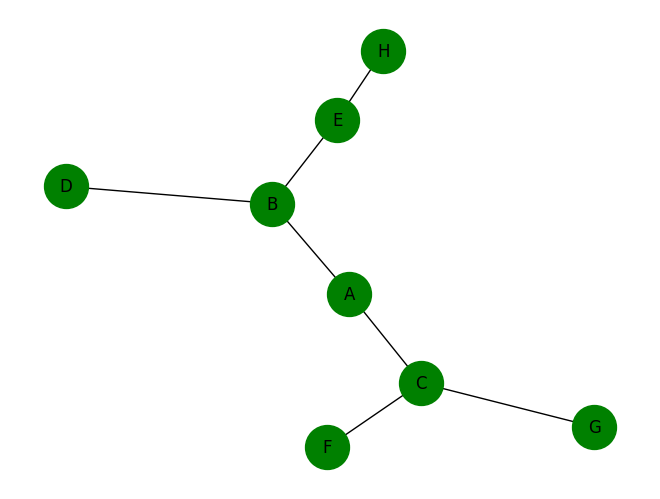

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
G=nx.Graph()

edges=[
    ('A','B'),('A','C'),
    ('B','D'),('B','E'),
    ('C','F'),('C','G'),
    ('E','H')
]
G.add_edges_from(edges)
nx.draw(G,with_labels=True,node_size=1000,node_color="green",font_size=12)
plt.show()

**BFS**

BFS Traversal:  ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


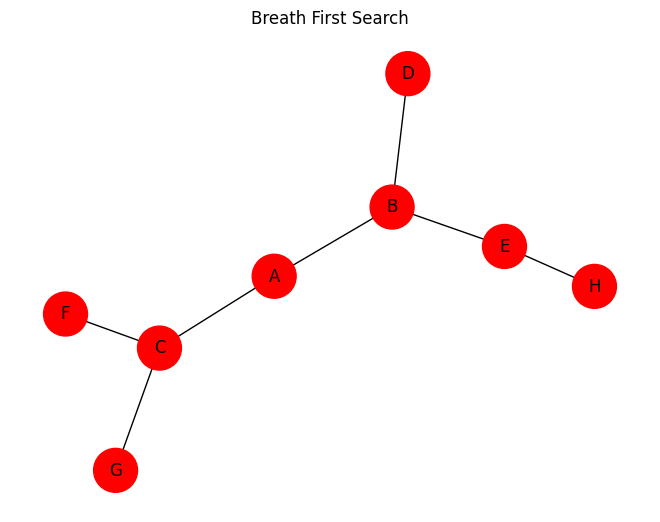

In [4]:
start = 'A'
visited=[]
queue =deque([start])

while queue:
  node=queue.popleft()
  if node not in visited:
    visited.append(node)
    queue.extend(sorted(set(G.neighbors(node)) -set(visited)))
print("BFS Traversal: ",visited)

#draw Graph
pos=nx.spring_layout(G,seed=42)
node_color=['red' if node in visited else 'blue' for node in G.nodes()]
nx.draw(G,pos,with_labels=True,node_size=1000,node_color=node_color,font_size=12)
plt.title("Breath First Search")
plt.show()


BFS Traversal Order:  ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


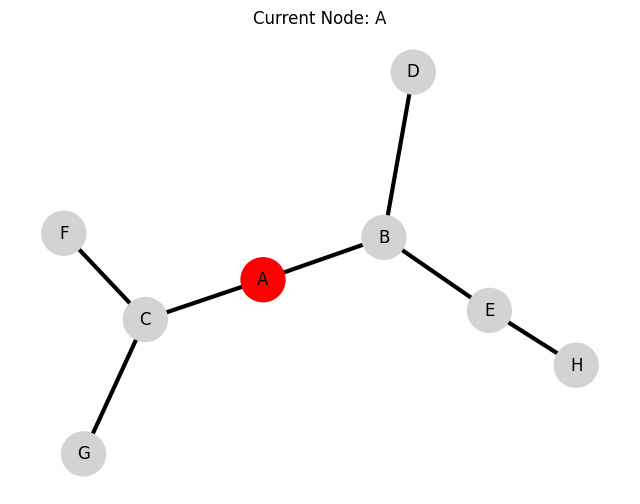

In [9]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from collections import deque

#BFS Travels
start = 'A'
visited=[]
parent={}
queue = deque({'A'})
while queue:
  node=queue.popleft()
  if node not in visited:
    visited.append(node)
    for neighbor in G.neighbors(node):
      if neighbor not in visited and neighbor not in queue:
        parent[neighbor]=node
        queue.append(neighbor)

print("BFS Traversal Order: ",visited)

#graph layout
pos=nx.spring_layout(G,seed=5)
fig, ax=plt.subplots(figsize=(8,6))

#Animation Function

def update(frame):
  ax.clear()
  visited_now=visited[:frame+1]
  node_color=['red' if n in visited_now else 'lightgray' for n in G.nodes()]
  edges_colors=[]
  for u,v in G.edges():
    if((v in parent and parent[v]==u and v in visited_now) or (u in parent and parent[u]==v and u in visited_now)):
      edges_colors.append('green')
    else:
      edges_colors.append('black')
  nx.draw(G,pos,with_labels=True,node_size=1000,node_color=node_color,edge_color=edges_colors,ax=ax,width=3)
  ax.set_title(
      f"Current Node: {visited[frame]}"
  )

#generate animation
ani=FuncAnimation(
    fig,
    update,
    frames=len(visited),
    interval=1200,
    repeat=False
 )

#display
HTML(ani.to_jshtml())


DFS Traversal Order: ['A', 'D', 'I', 'C', 'H', 'G', 'B', 'F', 'E']


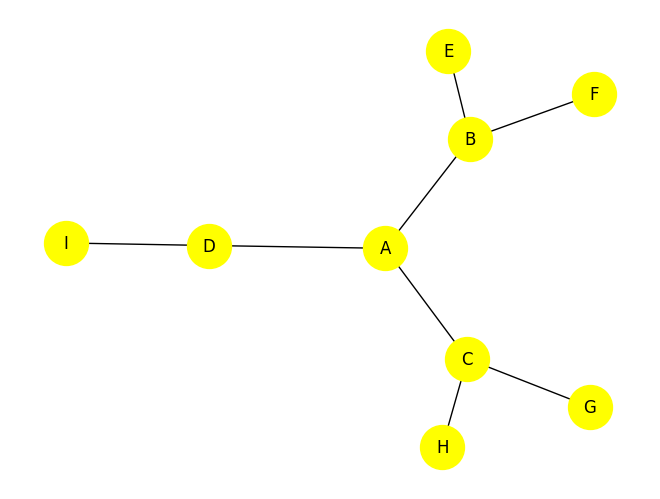

In [24]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
G=nx.Graph()

edges=[
    ('A','B'),('A','C'),('A','D'),
    ('B','E'),('B','F'),
    ('C','G'),('C','H'),
    ('D','I')
]
G.add_edges_from(edges)

# DFS Traversal
start_node = 'A'
dfs_visited = []
dfs_parent = {}
stack = [start_node]

while stack:
  node = stack.pop()
  if node not in dfs_visited:
    dfs_visited.append(node)
    for neighbor in G.neighbors(node):
      if neighbor not in dfs_visited:
          dfs_parent[neighbor] = node
          stack.append(neighbor)
print("DFS Traversal Order:", dfs_visited)
nx.draw(G,with_labels=True,node_size=1000,node_color="yellow",font_size=12)
plt.show()